<a href="https://colab.research.google.com/github/ajmalbuffy/Cricket-Analytics-ML-Project/blob/main/IPL_Match_Prediction_End_to_End_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPL Match Outcome Prediction and Performance Analysis using Machine Learning

This project analyzes historical Indian Premier League (IPL) cricket data to understand match patterns, team performance, and predict match outcomes using machine learning techniques.

The project demonstrates an end-to-end data science workflow including:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Statistical analysis
- Feature engineering
- Supervised learning models
- Unsupervised learning techniques
- Hyperparameter tuning
- Model evaluation and performance comparison

The goal is to apply data science and machine learning techniques to extract insights from IPL data and build predictive models.

## Dataset Description

This project uses publicly available IPL datasets that contain detailed information about matches and ball-by-ball deliveries from the Indian Premier League.

The analysis is performed using two datasets:

### 1. matches.csv
This dataset contains match-level information for IPL games.

Important attributes include:
- season
- team1
- team2
- toss_winner
- toss_decision
- venue
- winner
- win_by_runs
- win_by_wickets
- player_of_match

Each row represents one IPL match.

### 2. deliveries.csv
This dataset contains ball-by-ball information for each match.

Important attributes include:
- match_id
- inning
- batting_team
- bowling_team
- over
- ball
- batsman
- bowler
- batsman_runs
- total_runs
- dismissal_kind

Each row represents one ball delivered in a match.

## Data Source

The datasets used in this project are publicly available IPL datasets commonly used for academic research and data science practice.

Source:
Kaggle IPL Dataset  
https://www.kaggle.com/datasets

These datasets are shared for educational and analytical purposes and contain historical cricket match data.

This project is created strictly for:
- educational purposes
- data science practice
- machine learning demonstration

No proprietary or sensitive data is used.

## Project Workflow

This project follows a structured machine learning workflow:

1. Data Loading
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Statistical Analysis
5. Feature Engineering
6. Supervised Learning Models
7. Model Evaluation
8. Hyperparameter Tuning
9. Unsupervised Learning (Clustering)
10. Model Performance Comparison
11. Basic Model Deployment Concepts

## Libraries Used

The following Python libraries are used in this project:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TensorFlow / Keras (for basic neural network demonstration)


## Data Loading and Initial Data Inspection

In this step, the IPL datasets are loaded into the notebook using the Pandas library.  
The datasets include match-level information and ball-by-ball delivery data.

The purpose of this step is to understand the structure of the data and inspect the first few rows.

In [2]:
import pandas as pd
import numpy as np

In [9]:
match = pd.read_csv('/content/matches.csv')
delivery = pd.read_csv('/content/deliveries.csv')

In [10]:
match.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [11]:
match.tail()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon


In [12]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [13]:
delivery.tail()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260919,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,3,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN


## Dataset Shape

The `.shape` function is used to check the dimensions of the dataset.  
It returns the number of rows and columns in the data.  
This helps us understand how large the dataset is before starting data preprocessing and analysis.

In [14]:
print('Match dataset shape', match.shape)

Match dataset shape (1095, 20)


In [15]:
print('Deliveries dataset shape', delivery.shape)

Deliveries dataset shape (260920, 17)


## Dataset Information

The `.info()` function is used to get a summary of the dataset.  
It provides information about the columns, data types, number of non-null values, and memory usage.  
This helps in understanding the structure of the dataset before preprocessing.

In [16]:
match.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

## Missing Values Observation

Although the dataset contains 1095 rows, some columns show fewer non-null values in the `.info()` output.  
This indicates the presence of missing values in those columns. These missing values will need to be handled during the data preprocessing stage.

In [17]:
delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## Descriptive Statistics

The `.describe()` function is used to generate summary statistics of numerical columns in the dataset.  
It provides information such as count, mean, standard deviation, minimum value, maximum value, and quartiles.  
This helps in understanding the distribution and basic statistical properties of the data.

In [18]:
match.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [19]:
delivery.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


## Checking Missing Values

The `isnull().sum()` function is used to identify missing values in each column of the dataset.  
It returns the total number of null (missing) values present in every column, which helps determine whether data cleaning or preprocessing is required before analysis.

In [20]:
match.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [21]:
delivery.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


## Checking Unique Values

The `unique()` or `nunique()` function is used to identify the distinct values present in a column.  
This helps in understanding the different categories or labels in the dataset and is useful during data exploration and preprocessing.

In [22]:
delivery['batting_team'].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Kings XI Punjab', 'Rajasthan Royals',
       'Delhi Daredevils', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [23]:
delivery['batting_team'].nunique()

19

In [24]:
#Unique teams in a match dataset
match['team1'].nunique()

19

In [25]:
#Unique players in delivery dataset
delivery['batter'].nunique()

673

In [26]:
match.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [27]:
delivery.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

## Data Types of Columns

The `dtypes` attribute is used to display the data type of each column in the dataset.  
It helps identify whether a column contains integers, floats, or categorical (object) values, which is important for data preprocessing and machine learning preparation.

In [28]:
match.dtypes

,0
id,int64
season,object
city,object
date,object
match_type,object
player_of_match,object
venue,object
team1,object
team2,object
toss_winner,object


In [29]:
delivery.dtypes

,0
match_id,int64
inning,int64
batting_team,object
bowling_team,object
over,int64
ball,int64
batter,object
bowler,object
non_striker,object
batsman_runs,int64


## Random Sample of Data

The `sample()` function is used to display a random selection of rows from the dataset.  
This helps quickly inspect different records in the dataset and understand the data distribution without viewing the entire dataset.

In [30]:
match.sample(6)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
82,392207,2009,Port Elizabeth,2009-05-03,League,DPMD Jayawardene,St George's Park,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,bat,Kings XI Punjab,wickets,6.0,154.0,20.0,N,NaN,S Asnani,MR Benson
229,501253,2011,Chennai,2011-05-12,League,MS Dhoni,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,bat,Chennai Super Kings,runs,18.0,177.0,20.0,N,NaN,AM Saheba,SL Shastri
673,1136598,2018,Indore,2018-05-06,League,Mujeeb Ur Rahman,Holkar Cricket Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,6.0,153.0,20.0,N,NaN,C Shamshuddin,S Ravi
525,980917,2016,Mumbai,2016-04-16,League,AJ Finch,Wankhede Stadium,Mumbai Indians,Gujarat Lions,Gujarat Lions,field,Gujarat Lions,wickets,3.0,144.0,20.0,N,NaN,HDPK Dharmasena,VK Sharma
347,598022,2013,Kolkata,2013-04-20,League,RA Jadeja,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,bat,Chennai Super Kings,wickets,4.0,120.0,20.0,N,NaN,Asad Rauf,AK Chaudhary
41,336025,2007/08,Kolkata,2008-05-18,League,M Ntini,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,bat,Chennai Super Kings,runs,3.0,53.0,8.0,N,D/L,Asad Rauf,K Hariharan


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to explore and understand the patterns, trends, and relationships within the dataset.

Through visualization and statistical summaries, EDA helps identify important insights, detect anomalies, and understand how different variables influence the outcomes. This step is essential before building machine learning models, as it helps in selecting relevant features and making informed preprocessing decisions.

**Step:1 Aggregate Batsman Performance**

## Player Performance Aggregation

In this step, the dataset is grouped to analyze player performance.  
Total runs scored by each batsman are calculated to evaluate batting performance, and total runs conceded by each bowler are calculated to evaluate bowling performance.  

This aggregation helps identify the top-performing batsmen and bowlers in the IPL dataset.

In [31]:
#Aggregate Batsman Performance
#Step:1 Aggregate Batsman Performance
batting_performance = delivery.groupby(['batter'])['batsman_runs'].sum().reset_index()
batting_performance.rename(columns={'batsman_runs':'total_runs'},inplace=True)

#Aggregate Bowler Performance
bowler_performance = delivery.groupby(['bowler'])['total_runs'].sum().reset_index()
bowler_performance.rename(columns={'total_runs':'runs_conceded'}, inplace=True)

#Display the top 5 batsmen
batting_performance.sort_values(by='total_runs',ascending=False).head(5)

,batter,total_runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536


In [36]:
#Display the top 5 bowlers
bowler_performance.sort_values(by='runs_conceded', ascending=True)

,bowler,runs_conceded
24,AC Gilchrist,0
114,DA Warner,2
64,Atharva Taide,4
447,SPD Smith,5
38,AM Rahane,5
...,...,...
524,YS Chahal,4681
373,RA Jadeja,4917
71,B Kumar,5051
348,PP Chawla,5179


## Analyzing Team Performance Across Seasons

In this step, team performance is analyzed across different IPL seasons to identify trends and patterns in match outcomes. This helps understand how teams have performed over time and provides insights into consistent or changing team performance across seasons.

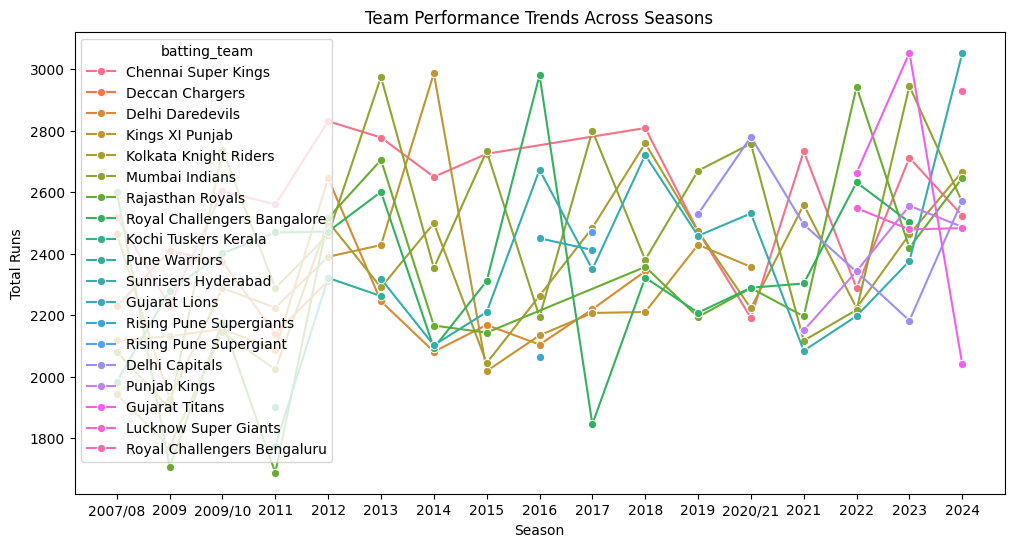

In [37]:
#Merge Deliveries and Match Data
deliveries_with_season = pd.merge(delivery, match[['id', 'season']], left_on='match_id', right_on='id')

#Aggregate Team Performance by Season
team_season_performance = deliveries_with_season.groupby(['season', 'batting_team'])['total_runs'].sum().reset_index()


#Line plot to visualize the team performance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=team_season_performance, x='season', y='total_runs', hue='batting_team', marker='o')
plt.title('Team Performance Trends Across Seasons')
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.show()

<Axes: xlabel='season', ylabel='total_runs'>

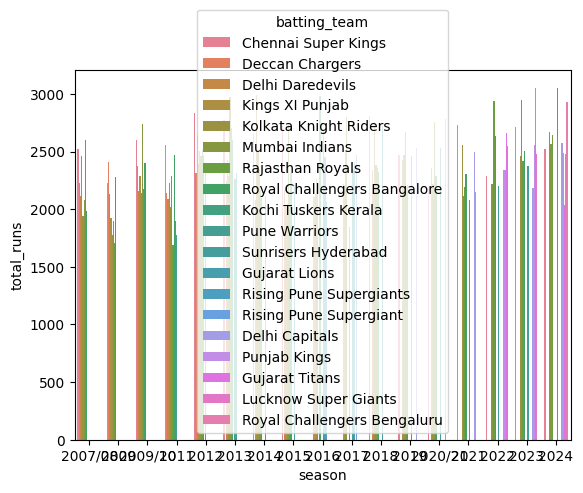

In [38]:
sns.barplot(data=team_season_performance, x='season', y='total_runs', hue='batting_team')

<Axes: xlabel='season'>

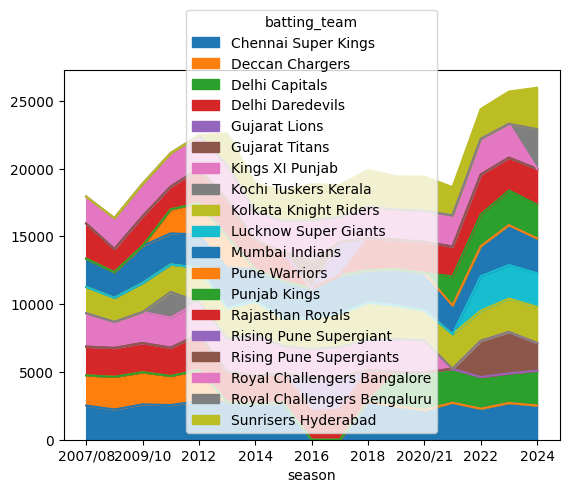

In [39]:
team_season_performance.pivot(index='season', columns='batting_team', values='total_runs').plot.area()

# Analyzing Player Performance Across Seasons

In [42]:
#Aggregate Player Performance by Season
player_season_performance = deliveries_with_season.groupby(['season', 'batter']).agg({
    'batsman_runs':'sum',
    'ball':'count'
}).reset_index()

#Strike rate calculation
player_season_performance['strike_rate'] = (player_season_performance['batsman_runs'] / player_season_performance['ball']) * 100

#Finding top players
top_players = player_season_performance.groupby('batter')['batsman_runs'].sum().nlargest(5).index
filtered_data = player_season_performance[player_season_performance['batter'].isin(top_players)]

## Resetting the Index

After using `groupby()`, the grouped columns (in this case `season` and `batter`) become the index of the resulting dataframe.  
The `reset_index()` function is used to convert these index values back into normal columns so the dataframe can be easily used for further analysis, visualization, or modeling.

## Player Performance Trends Across Seasons

A line plot is used to visualize the performance of top players across different IPL seasons.
Since seasons represent a time-based sequence, the line plot helps show how the total runs and strike rates of players change over time and allows easy comparison between players.

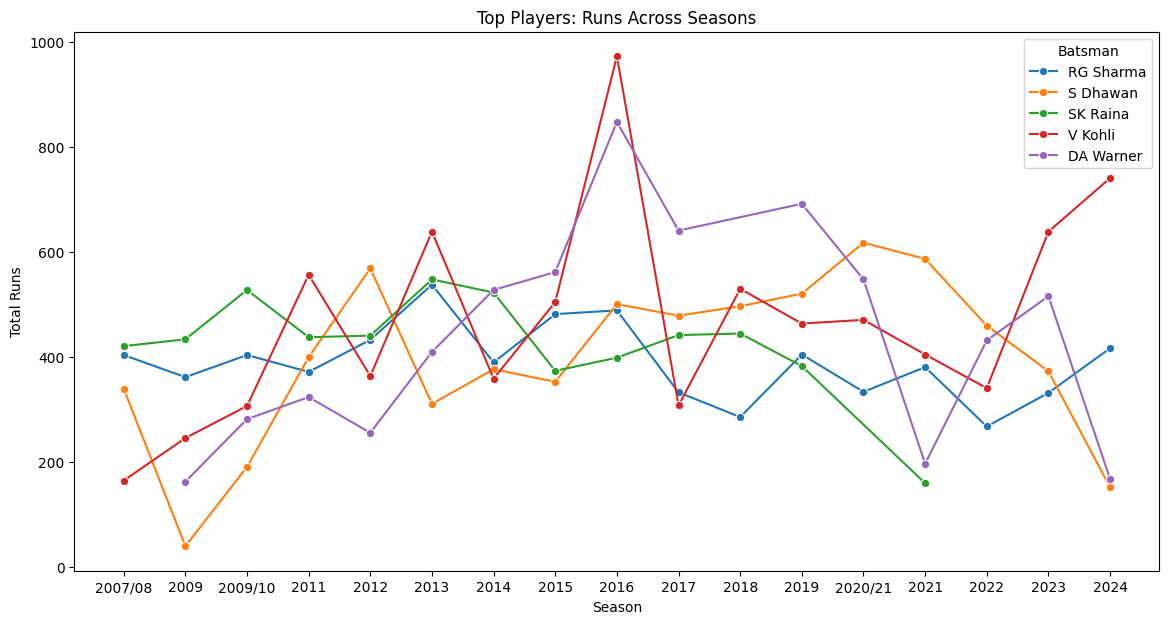

In [43]:
#Visualize Player Performance

plt.figure(figsize=(14, 7))
sns.lineplot(data=filtered_data, x='season', y='batsman_runs', hue='batter', marker='o')
plt.title('Top Players: Runs Across Seasons')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.legend(title='Batsman')
plt.show()

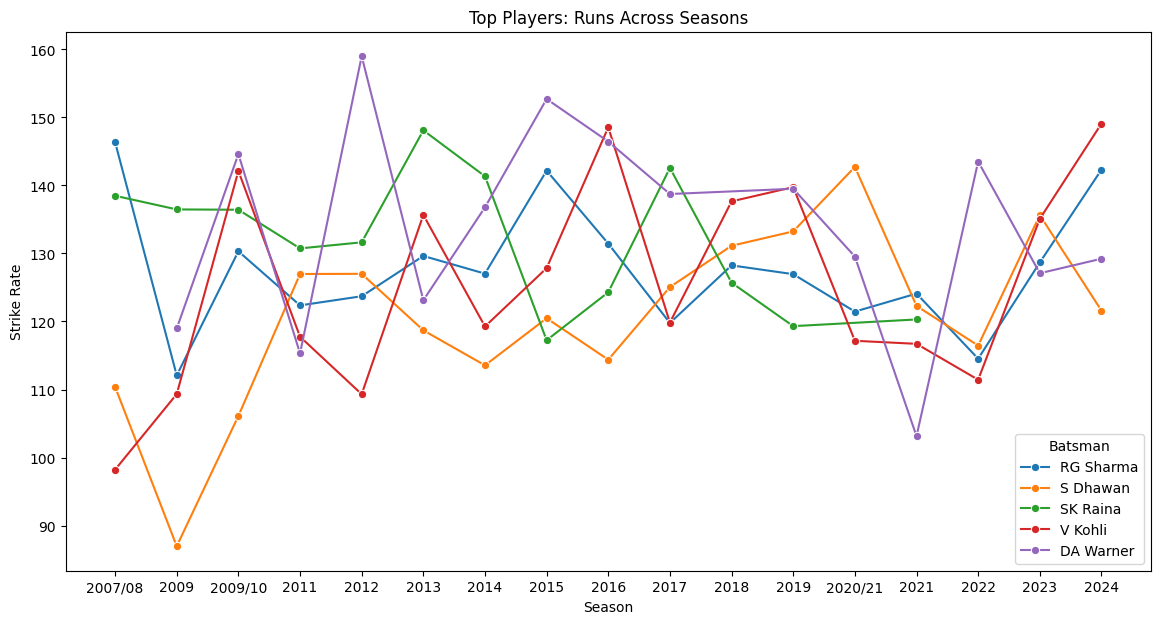

In [44]:
#Strike Rates of Top Players
plt.figure(figsize=(14, 7))
sns.lineplot(data=filtered_data, x='season', y='strike_rate', hue='batter', marker='o')
plt.title('Top Players: Runs Across Seasons')
plt.xlabel('Season')
plt.ylabel('Strike Rate')
plt.legend(title='Batsman')
plt.show()

# Team Performance Comparison

In [45]:
#Aggregate team performance by season

team_performance = deliveries_with_season.groupby(['season', 'batting_team']).agg({
    'total_runs':'sum'
}).reset_index()

In [46]:
team_performance

,season,batting_team,total_runs
0,2007/08,Chennai Super Kings,2520
1,2007/08,Deccan Chargers,2229
2,2007/08,Delhi Daredevils,2118
3,2007/08,Kings XI Punjab,2464
4,2007/08,Kolkata Knight Riders,1942
...,...,...,...
141,2024,Mumbai Indians,2568
142,2024,Punjab Kings,2487
143,2024,Rajasthan Royals,2647
144,2024,Royal Challengers Bengaluru,2930


In [47]:
#Aggregating Total Wickets Taken by Teams Across Seasons
wickets = deliveries_with_season[deliveries_with_season['dismissal_kind'].notnull()]
team_wickets = wickets.groupby(['season', 'bowling_team']).size().reset_index(name='total_wickets')

In [48]:
team_wickets

,season,bowling_team,total_wickets
0,2007/08,Chennai Super Kings,93
1,2007/08,Deccan Chargers,67
2,2007/08,Delhi Daredevils,96
3,2007/08,Kings XI Punjab,95
4,2007/08,Kolkata Knight Riders,70
...,...,...,...
141,2024,Mumbai Indians,85
142,2024,Punjab Kings,101
143,2024,Rajasthan Royals,96
144,2024,Royal Challengers Bengaluru,88


In [49]:
wickets

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season
33,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,5,2,SC Ganguly,Z Khan,BB McCullum,0,0,0,NaN,1,SC Ganguly,caught,JH Kallis,335982,2007/08
74,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,12,1,RT Ponting,JH Kallis,BB McCullum,0,0,0,NaN,1,RT Ponting,caught,P Kumar,335982,2007/08
106,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,17,1,DJ Hussey,AA Noffke,BB McCullum,0,0,0,NaN,1,DJ Hussey,caught,CL White,335982,2007/08
131,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,1,1,R Dravid,I Sharma,W Jaffer,0,0,0,NaN,1,R Dravid,bowled,NaN,335982,2007/08
138,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,2,2,V Kohli,AB Dinda,W Jaffer,0,0,0,NaN,1,V Kohli,bowled,NaN,335982,2007/08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260826,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,14,1,H Klaasen,Harshit Rana,PJ Cummins,0,0,0,NaN,1,H Klaasen,bowled,NaN,1426312,2024
260848,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,17,5,JD Unadkat,SP Narine,PJ Cummins,0,0,0,NaN,1,JD Unadkat,lbw,NaN,1426312,2024
260852,1426312,1,Sunrisers Hyderabad,Kolkata Knight Riders,18,3,PJ Cummins,AD Russell,B Kumar,0,0,0,NaN,1,PJ Cummins,caught,MA Starc,1426312,2024
260861,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,1,2,SP Narine,PJ Cummins,Rahmanullah Gurbaz,0,0,0,NaN,1,SP Narine,caught,Shahbaz Ahmed,1426312,2024


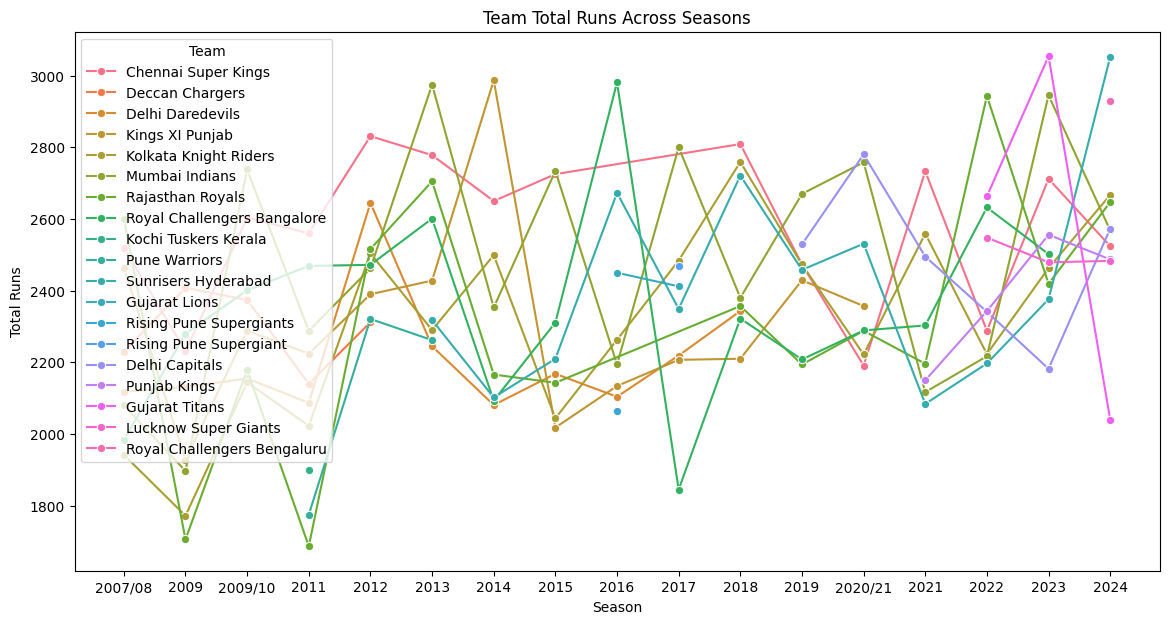

In [50]:
#Visualizing Team Performance - Total Runs
plt.figure(figsize=(14, 7))
sns.lineplot(data=team_performance, x='season', y='total_runs', hue='batting_team', marker='o')
plt.title('Team Total Runs Across Seasons')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.legend(title='Team')
plt.show()

# Powerplay and Death Over Analysis

In [51]:
#Filter Powerplay Deliveries
powerplay_deliveries = deliveries_with_season[deliveries_with_season['over'] <= 6 ]
powerplay_deliveries

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2007/08
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2007/08
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260894,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,6,2,Rahmanullah Gurbaz,Shahbaz Ahmed,VR Iyer,0,4,4,byes,0,NaN,NaN,NaN,1426312,2024
260895,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,6,3,Rahmanullah Gurbaz,Shahbaz Ahmed,VR Iyer,6,0,6,NaN,0,NaN,NaN,NaN,1426312,2024
260896,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,6,4,Rahmanullah Gurbaz,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN,1426312,2024
260897,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,6,5,VR Iyer,Shahbaz Ahmed,Rahmanullah Gurbaz,0,1,1,legbyes,0,NaN,NaN,NaN,1426312,2024


In [52]:
powerplay_performance = powerplay_deliveries.groupby(['season', 'batting_team']).agg({
    'total_runs': 'sum',
    'player_dismissed': 'count'
}).reset_index()

powerplay_performance.rename(columns={'player_dismissed': 'wickets_lost'}, inplace=True)
powerplay_performance

,season,batting_team,total_runs,wickets_lost
0,2007/08,Chennai Super Kings,848,25
1,2007/08,Deccan Chargers,738,21
2,2007/08,Delhi Daredevils,841,26
3,2007/08,Kings XI Punjab,885,22
4,2007/08,Kolkata Knight Riders,604,32
...,...,...,...,...
141,2024,Mumbai Indians,910,27
142,2024,Punjab Kings,843,26
143,2024,Rajasthan Royals,867,23
144,2024,Royal Challengers Bengaluru,993,24


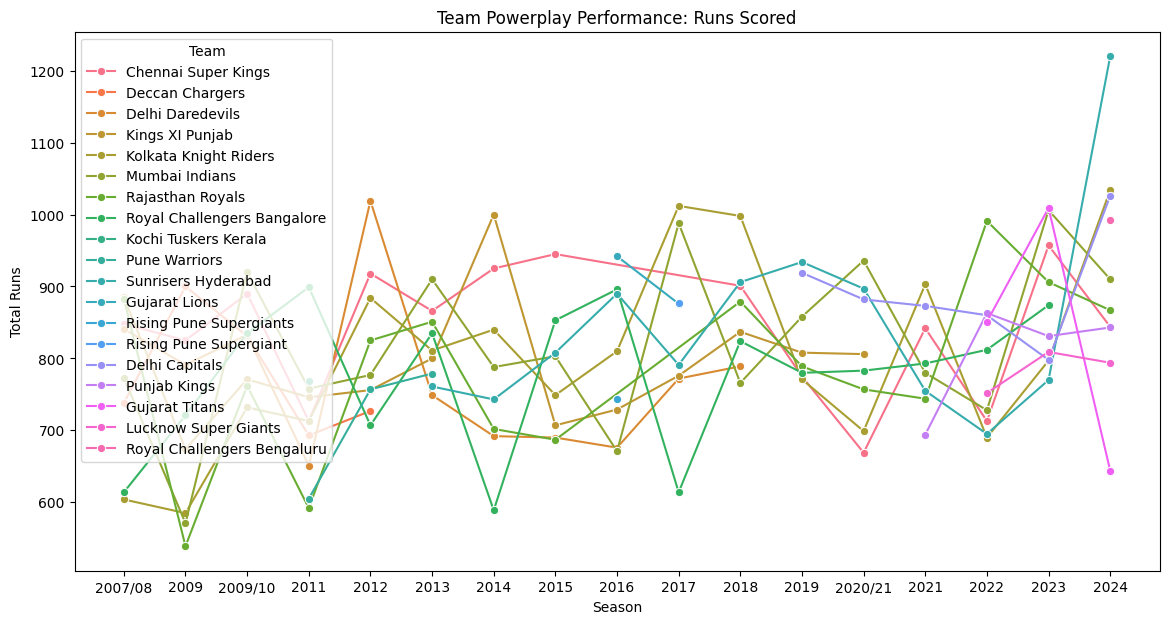

In [54]:
#Plotting powerplay performance (runs scored)
plt.figure(figsize=(14, 7))
sns.lineplot(data=powerplay_performance, x='season', y='total_runs', hue='batting_team', marker='o')
plt.title('Team Powerplay Performance: Runs Scored')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.legend(title='Team')
plt.show()

<Axes: xlabel='season', ylabel='total_runs'>

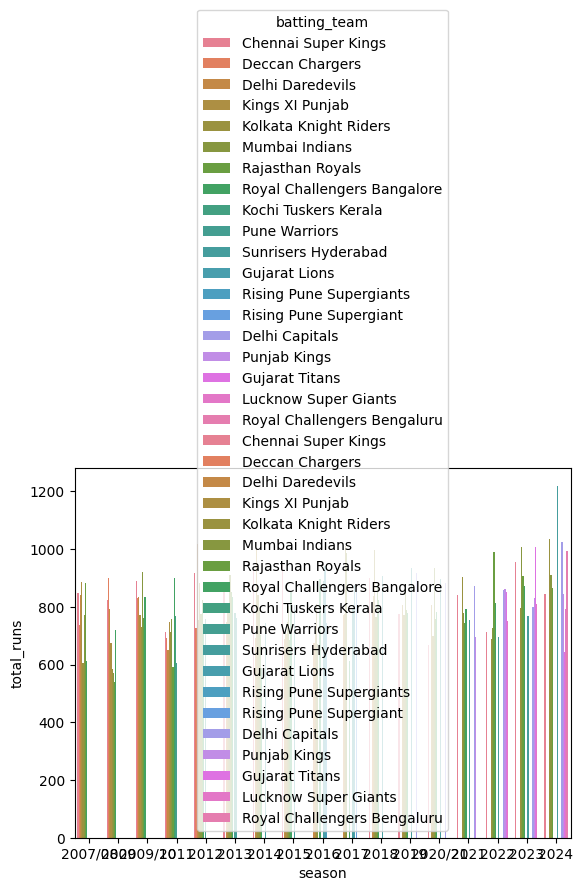

In [53]:
#Visualizing the data
#Bar plot for runs scored
sns.barplot(data=powerplay_performance, x='season', y='total_runs', hue='batting_team')
#Bar plot for wickets lost
sns.barplot(data=powerplay_performance, x='season', y='wickets_lost', hue='batting_team')

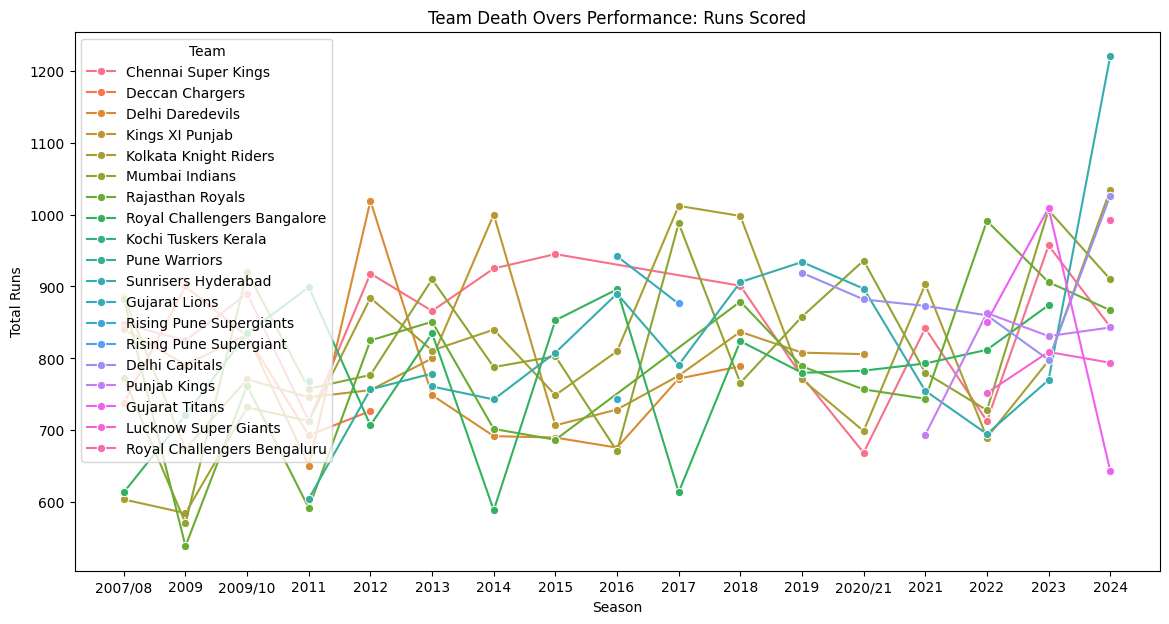

In [56]:
#Filter deliveries in death overs
death_overs_deliveries = deliveries_with_season[deliveries_with_season['over'] >=17]

#Aggregate team performance in death overs
death_overs_performance = death_overs_deliveries.groupby(['season', 'batting_team']).agg({
    'total_runs': 'sum',
    'player_dismissed': 'count'
}).reset_index()
death_overs_performance.rename(columns={'player_dismissed': 'wickets_lost'}, inplace=True)

#Plotting death overs performance (runs scored)
plt.figure(figsize=(14, 7))
sns.lineplot(data=powerplay_performance, x='season', y='total_runs', hue='batting_team', marker='o')
plt.title('Team Death Overs Performance: Runs Scored')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.legend(title='Team')
plt.show()

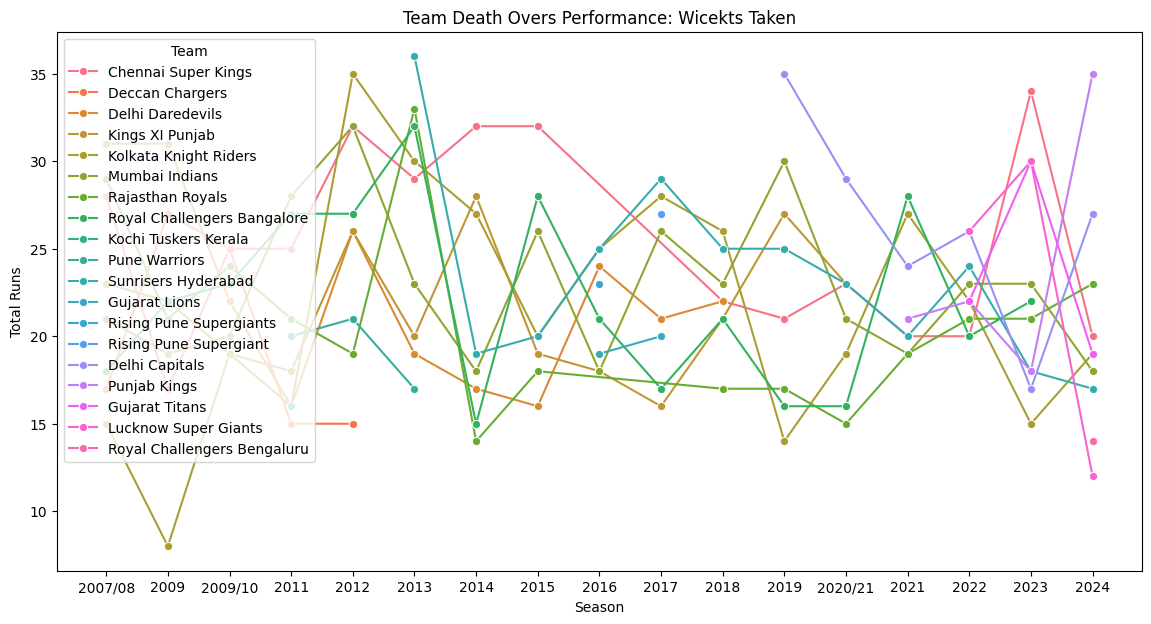

In [57]:
#Aggregate team bowling performance in death overs
death_overs_bowling = death_overs_deliveries.groupby(['season', 'bowling_team']).agg({
    'player_dismissed': 'count'
}).reset_index()

death_overs_bowling.rename(columns={'player_dismissed': 'wickets_taken'}, inplace=True)

#Plotting death overs performance (wickets taken)
plt.figure(figsize=(14, 7))
sns.lineplot(data=death_overs_bowling, x='season', y='wickets_taken', hue='bowling_team', marker='o')
plt.title('Team Death Overs Performance: Wicekts Taken')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.legend(title='Team')
plt.show()

# IPL Win Probability Prediction Using Machine Learning

## Grouping Total Runs by Match and Innings

In this step, the ball-by-ball delivery data is grouped by `match_id` and `inning` to calculate the total runs scored in each innings of every match.

This aggregation converts detailed delivery-level data into match-level information, making it easier to analyze team scores and use the data for further analysis or machine learning tasks.

In [58]:
#Grouping Total Runs by Match and Innings
delivery.groupby(['match_id', 'inning']).sum()['total_runs']

match_id  inning
335982    1         222
          2          82
335983    1         240
          2         207
335984    1         129
                   ... 
1426310   2         174
1426311   1         175
          2         139
1426312   1         113
          2         114
Name: total_runs, Length: 2217, dtype: int64

In [59]:
#Create a dataframe for total runs
total_score_df = delivery.groupby(['match_id', 'inning']).sum()['total_runs'].reset_index()
total_score_df

,match_id,inning,total_runs
0,335982,1,222
1,335982,2,82
2,335983,1,240
3,335983,2,207
4,335984,1,129
...,...,...,...
2212,1426310,2,174
2213,1426311,1,175
2214,1426311,2,139
2215,1426312,1,113


## DataFrame

A DataFrame is a two-dimensional data structure in the Pandas library used to store and organize data in rows and columns, similar to a table or spreadsheet.

It allows easy data manipulation, analysis, and processing by providing various functions for filtering, grouping, and transforming data.

In [60]:
#Filtering first innings data
total_score_df = total_score_df[total_score_df['inning'] == 1]
total_score_df

,match_id,inning,total_runs
0,335982,1,222
2,335983,1,240
4,335984,1,129
6,335985,1,165
8,335986,1,110
...,...,...,...
2207,1426307,1,214
2209,1426309,1,159
2211,1426310,1,172
2213,1426311,1,175


In [61]:
#Merge total runs with match data
match_df = match.merge(total_score_df[['match_id', 'total_runs']], left_on='id', right_on='match_id')
match_df

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,match_id,total_runs
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,335982,222
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,335983,240
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,335984,129
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,335985,165
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,335986,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,...,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma,1426307,214
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,...,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit,1426309,159
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,...,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar,1426310,172
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,...,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma,1426311,175


In [62]:
match_df['team1'].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [63]:
teams = [
    "Chennai Super Kings",
    "Mumbai Indians",
    "Kolkata Knight Riders",
    "Rajasthan Royals",
    "Royal Challengers Bengaluru",
    "Delhi Capitals",
    "Punjab Kings",
    "Sunrisers Hyderabad",
    "Gujarat Titans",
    "Lucknow Super Giants"
]

In [64]:
match_df['team1'] = match_df['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
match_df['team2'] = match_df['team2'].str.replace('Delhi Daredevils','Delhi Capitals')

match_df['team1'] = match_df['team1'].str.replace('Kings XI Punjab','Punjab Kings')
match_df['team2'] = match_df['team2'].str.replace('Kings XI Punjab','Punjab Kings')

match_df['team1'] = match_df['team1'].str.replace('Deccan Chargers','Sunrisers Hyderabad')
match_df['team2'] = match_df['team2'].str.replace('Deccan Chargers','Sunrisers Hyderabad')

match_df['team1'] = match_df['team1'].str.replace('Rising Pune Supergiants','Rising Pune Supergiant')
match_df['team2'] = match_df['team2'].str.replace('Rising Pune Supergiants','Rising Pune Supergiant')

In [65]:
match_df.shape

(1095, 22)

In [66]:
match_df = match_df[match_df['team1'].isin(teams)]
match_df = match_df[match_df['team2'].isin(teams)]

In [67]:
match_df.shape

(756, 22)

In [68]:
match_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,match_id,total_runs
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,335983,240
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,335984,129
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Sunrisers Hyderabad,Deccan Chargers,...,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,335986,110
5,335987,2007/08,Jaipur,2008-04-21,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Punjab Kings,Kings XI Punjab,...,wickets,6.0,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin,335987,166
6,335988,2007/08,Hyderabad,2008-04-22,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Delhi Capitals,Deccan Chargers,...,wickets,9.0,143.0,20.0,N,NaN,IL Howell,AM Saheba,335988,142


In [70]:
match_df = match_df[['match_id','city','winner','total_runs']]
match_df

,match_id,city,winner,total_runs
1,335983,Chandigarh,Chennai Super Kings,240
2,335984,Delhi,Delhi Daredevils,129
4,335986,Kolkata,Kolkata Knight Riders,110
5,335987,Jaipur,Rajasthan Royals,166
6,335988,Hyderabad,Delhi Daredevils,142
...,...,...,...,...
1090,1426307,Hyderabad,Sunrisers Hyderabad,214
1091,1426309,Ahmedabad,Kolkata Knight Riders,159
1092,1426310,Ahmedabad,Rajasthan Royals,172
1093,1426311,Chennai,Sunrisers Hyderabad,175


In [85]:
#In delivery i have all the ball related data
delivery_df = match_df.merge(delivery,on='match_id')
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs_y,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335983,Chandigarh,Chennai Super Kings,240,1,Chennai Super Kings,Kings XI Punjab,0,1,PA Patel,B Lee,ML Hayden,0,0,0,NaN,0,NaN,NaN,NaN
1,335983,Chandigarh,Chennai Super Kings,240,1,Chennai Super Kings,Kings XI Punjab,0,2,PA Patel,B Lee,ML Hayden,0,0,0,NaN,0,NaN,NaN,NaN
2,335983,Chandigarh,Chennai Super Kings,240,1,Chennai Super Kings,Kings XI Punjab,0,3,PA Patel,B Lee,ML Hayden,1,0,1,NaN,0,NaN,NaN,NaN
3,335983,Chandigarh,Chennai Super Kings,240,1,Chennai Super Kings,Kings XI Punjab,0,4,ML Hayden,B Lee,PA Patel,0,0,0,NaN,0,NaN,NaN,NaN
4,335983,Chandigarh,Chennai Super Kings,240,1,Chennai Super Kings,Kings XI Punjab,0,5,ML Hayden,B Lee,PA Patel,4,0,4,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181208,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
181209,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
181210,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
181211,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN


In [86]:
#innings 2 for chasing details
delivery_df = delivery_df[delivery_df['inning'] == 2]
delivery_df.head()

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs_y,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
124,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,1,K Goel,JDP Oram,JR Hopes,4,0,4,NaN,0,NaN,NaN,NaN
125,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,2,K Goel,JDP Oram,JR Hopes,0,0,0,NaN,0,NaN,NaN,NaN
126,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,3,K Goel,JDP Oram,JR Hopes,0,0,0,NaN,0,NaN,NaN,NaN
127,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,4,K Goel,JDP Oram,JR Hopes,1,0,1,NaN,0,NaN,NaN,NaN
128,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,5,JR Hopes,JDP Oram,K Goel,0,0,0,NaN,0,NaN,NaN,NaN


In [87]:
#Calculate current score
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()
delivery_df

/tmp/ipykernel_529/3467747465.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs_y'].cumsum()


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,...,non_striker,batsman_runs,extra_runs,total_runs_y,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score
124,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,1,K Goel,...,JR Hopes,4,0,4,NaN,0,NaN,NaN,NaN,4
125,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,2,K Goel,...,JR Hopes,0,0,0,NaN,0,NaN,NaN,NaN,4
126,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,3,K Goel,...,JR Hopes,0,0,0,NaN,0,NaN,NaN,NaN,4
127,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,4,K Goel,...,JR Hopes,1,0,1,NaN,0,NaN,NaN,NaN,5
128,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,5,JR Hopes,...,K Goel,0,0,0,NaN,0,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181208,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,...,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN,110
181209,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,...,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN,111
181210,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,...,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN,112
181211,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,...,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN,113


In [88]:
delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']
delivery_df.head(3)

/tmp/ipykernel_529/3661522307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['runs_left'] = delivery_df['total_runs_x'] - delivery_df['current_score']


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,...,batsman_runs,extra_runs,total_runs_y,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left
124,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,1,K Goel,...,4,0,4,NaN,0,NaN,NaN,NaN,4,236
125,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,2,K Goel,...,0,0,0,NaN,0,NaN,NaN,NaN,4,236
126,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,3,K Goel,...,0,0,0,NaN,0,NaN,NaN,NaN,4,236


In [89]:
delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])
delivery_df.head(3)

/tmp/ipykernel_529/2513221445.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['balls_left'] = 126 - (delivery_df['over']*6 + delivery_df['ball'])


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,...,extra_runs,total_runs_y,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left
124,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,1,K Goel,...,0,4,NaN,0,NaN,NaN,NaN,4,236,125
125,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,2,K Goel,...,0,0,NaN,0,NaN,NaN,NaN,4,236,124
126,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,3,K Goel,...,0,0,NaN,0,NaN,NaN,NaN,4,236,123


In [90]:
delivery_df['player_dismissed']

,player_dismissed
124,NaN
125,NaN
126,NaN
127,NaN
128,NaN
...,...
181208,NaN
181209,NaN
181210,NaN
181211,NaN


In [91]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].fillna("0")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(lambda x:x if x == "0" else "1")
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].astype('int')

/tmp/ipykernel_529/117333967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['player_dismissed'] = delivery_df['player_dismissed'].fillna("0")
/tmp/ipykernel_529/117333967.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(lambda x:x if x == "0" else "1")
/tmp/ipykernel_529/117333967.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [92]:
delivery_df['player_dismissed']

,player_dismissed
124,0
125,0
126,0
127,0
128,0
...,...
181208,0
181209,0
181210,0
181211,0


In [93]:
wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum().values
list(wickets)

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.in

In [95]:
delivery_df['wickets'] = 10 - wickets
delivery_df.head(3)

/tmp/ipykernel_529/941863659.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['wickets'] = 10 - wickets


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,...,total_runs_y,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets
181210,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,...,1,NaN,0,0,NaN,NaN,112,1,65,8
181211,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,...,1,NaN,0,0,NaN,NaN,113,0,64,8
181212,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,3,VR Iyer,...,1,NaN,0,0,NaN,NaN,114,-1,63,8


In [97]:
delivery_df['crr'] = (delivery_df['current_score']*6)/(120 - delivery_df['balls_left'])

/tmp/ipykernel_529/2048085250.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['crr'] = (delivery_df['current_score']*6)/(120 - delivery_df['balls_left'])


In [98]:
delivery_df['rrr'] = (delivery_df['runs_left']*6)/(120 - delivery_df['balls_left'])

/tmp/ipykernel_529/2029666432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['rrr'] = (delivery_df['runs_left']*6)/(120 - delivery_df['balls_left'])


In [99]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,...,is_wicket,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets,crr,rrr
124,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,1,K Goel,...,0,0,NaN,NaN,4,236,125,10,-4.800000,-283.200000
125,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,2,K Goel,...,0,0,NaN,NaN,4,236,124,10,-6.000000,-354.000000
126,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,3,K Goel,...,0,0,NaN,NaN,4,236,123,10,-8.000000,-472.000000
127,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,4,K Goel,...,0,0,NaN,NaN,5,235,122,10,-15.000000,-705.000000
128,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,5,JR Hopes,...,0,0,NaN,NaN,5,235,121,10,-30.000000,-1410.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181208,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,...,0,0,NaN,NaN,110,3,67,8,12.452830,0.339623
181209,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,...,0,0,NaN,NaN,111,2,66,8,12.333333,0.222222
181210,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,...,0,0,NaN,NaN,112,1,65,8,12.218182,0.109091
181211,1426312,Chennai,Kolkata Knight Riders,113,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,...,0,0,NaN,NaN,113,0,64,8,12.107143,0.000000


In [100]:
def result(row):
  return 1 if row['batting_team'] == row['winner'] else 0

In [101]:
delivery_df['result'] = delivery_df.apply(result, axis=1)
delivery_df.head(3)

/tmp/ipykernel_529/2515948489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivery_df['result'] = delivery_df.apply(result, axis=1)


,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batter,...,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets,crr,rrr,result
124,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,1,K Goel,...,0,NaN,NaN,4,236,125,10,-4.8,-283.2,0
125,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,2,K Goel,...,0,NaN,NaN,4,236,124,10,-6.0,-354.0,0
126,335983,Chandigarh,Chennai Super Kings,240,2,Kings XI Punjab,Chennai Super Kings,0,3,K Goel,...,0,NaN,NaN,4,236,123,10,-8.0,-472.0,0


In [102]:
final_df = delivery_df[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr','result']]

In [103]:
final_df = final_df.sample(final_df.shape[0])
final_df

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
97143,Delhi Daredevils,Chennai Super Kings,Pune,15,6,5,211,10.315789,0.789474,0
112750,Mumbai Indians,Kolkata Knight Riders,Mumbai,74,82,9,133,9.315789,11.684211,1
128013,Rajasthan Royals,Kolkata Knight Riders,Mumbai,91,95,8,133,10.080000,21.840000,1
131178,Rajasthan Royals,Delhi Capitals,Abu Dhabi,106,64,6,154,5.142857,11.357143,0
53958,Kolkata Knight Riders,Kings XI Punjab,Kolkata,37,38,7,149,8.195122,2.707317,1
...,...,...,...,...,...,...,...,...,...,...
2976,Kings XI Punjab,Deccan Chargers,Hyderabad,131,103,10,164,11.647059,46.235294,1
173107,Gujarat Titans,Punjab Kings,Mohali,29,26,5,142,7.212766,1.851064,1
179281,Lucknow Super Giants,Delhi Capitals,Delhi,107,57,4,208,9.619048,10.190476,0
15798,Delhi Daredevils,Mumbai Indians,East London,43,37,8,116,5.277108,3.108434,1


In [104]:
final_df.tail()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
2976,Kings XI Punjab,Deccan Chargers,Hyderabad,131,103,10,164,11.647059,46.235294,1
173107,Gujarat Titans,Punjab Kings,Mohali,29,26,5,142,7.212766,1.851064,1
179281,Lucknow Super Giants,Delhi Capitals,Delhi,107,57,4,208,9.619048,10.190476,0
15798,Delhi Daredevils,Mumbai Indians,East London,43,37,8,116,5.277108,3.108434,1
144496,Kolkata Knight Riders,Rajasthan Royals,Mumbai,109,81,8,152,6.615385,16.769231,1


In [105]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87428 entries, 97143 to 144496
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   batting_team  87428 non-null  object 
 1   bowling_team  87428 non-null  object 
 2   city          83056 non-null  object 
 3   runs_left     87428 non-null  int64  
 4   balls_left    87428 non-null  int64  
 5   wickets       87428 non-null  int64  
 6   total_runs_x  87428 non-null  int64  
 7   crr           87404 non-null  float64
 8   rrr           87428 non-null  float64
 9   result        87428 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 7.3+ MB


In [106]:
final_df.dropna(inplace=True)

In [107]:
final_df = final_df[(120 - final_df['balls_left']) != 0]

In [108]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82338 entries, 97143 to 144496
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   batting_team  82338 non-null  object 
 1   bowling_team  82338 non-null  object 
 2   city          82338 non-null  object 
 3   runs_left     82338 non-null  int64  
 4   balls_left    82338 non-null  int64  
 5   wickets       82338 non-null  int64  
 6   total_runs_x  82338 non-null  int64  
 7   crr           82338 non-null  float64
 8   rrr           82338 non-null  float64
 9   result        82338 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 6.9+ MB


In [109]:
#Training process
X = final_df.iloc[:,:-1]
y = final_df.iloc[:,-1]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  OneHotEncoder

trf = ColumnTransformer([
    ('trf', OneHotEncoder(sparse_output=False,drop='first'),['batting_team','bowling_team','city'])
], remainder='passthrough')

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [114]:
pipe = Pipeline(steps=[
('step1',trf),
('step2',LogisticRegression(solver='liblinear'))
])

In [115]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('step1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'city'])])),
                ('step2', LogisticRegression(solver='liblinear'))])

In [116]:
X_train.describe()

,runs_left,balls_left,wickets,total_runs_x,crr,rrr
count,65870.000000,65870.000000,65870.000000,65870.000000,65870.000000,65870.000000
mean,93.046303,68.243282,7.474814,168.968165,9.071974,19.465428
std,50.711226,33.266476,2.153768,30.903196,7.733537,166.455723
min,-6.000000,4.000000,0.000000,67.000000,-132.000000,-1608.000000
25%,53.000000,40.000000,6.000000,148.000000,7.358491,3.325301
50%,92.000000,69.000000,8.000000,168.000000,8.769231,9.200000
75%,130.000000,97.000000,9.000000,188.000000,10.500000,25.935484
max,286.000000,125.000000,10.000000,287.000000,162.000000,1656.000000


In [117]:
y_pred = pipe.predict(X_test)

In [119]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8157031819285888


In [120]:
pipe.predict_proba(X_test)[10]

array([0.61454173, 0.38545827])

In [121]:
def match_summary(row):
  print("Batting Team-" + row['batting_team'] + " | Bowling Team-" + row['bowling_team'] + " | Target- " + str(row['total_runs_x']))


In [122]:
import numpy as np

def match_progression(x_df, match_id, pipe):
    # Filter the data for the given match_id
    match = x_df[x_df['match_id'] == match_id]

    # Consider only deliveries at the end of the over (ball 6)
    match = match[(match['ball'] == 6)]

    # Select relevant columns and drop NaN values
    temp_df = match[['batting_team', 'bowling_team', 'city', 'runs_left',
                     'balls_left', 'wickets', 'total_runs_x', 'crr', 'rrr']].dropna()

    # Ensure there are no rows with balls_left == 0
    temp_df = temp_df[temp_df['balls_left'] != 0]

    # Handle cases where temp_df is empty after filtering
    if temp_df.empty:
        print(f"No valid data for match_id: {match_id}")
        return None, None

    # Replace infinities or very large values
    temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    temp_df.dropna(inplace=True)

    # Predict probabilities using the pipeline
    try:
        result = pipe.predict_proba(temp_df)
    except ValueError as e:
        print(f"Error in prediction: {e}")
        return None, None

    # Add prediction results to temp_df
    temp_df['lose'] = np.round(result.T[0] * 100, 1)
    temp_df['win'] = np.round(result.T[1] * 100, 1)
    temp_df['end_of_over'] = range(1, temp_df.shape[0] + 1)

    # Calculate runs after over and wickets in over
    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0, target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)

    wickets = list(temp_df['wickets'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0, 10)
    wickets.append(0)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[:temp_df.shape[0]]

    print("Target:", target)
    temp_df = temp_df[['end_of_over', 'runs_after_over', 'wickets_in_over', 'lose', 'win']]
    return temp_df, target

In [123]:
temp_df,target = match_progression(delivery_df,1426312 ,pipe)

Target: 113


In [124]:
temp_df

,end_of_over,runs_after_over,wickets_in_over,lose,win
181158,1,17,1,8.6,91.4
181165,2,20,0,3.2,96.8
181171,3,7,0,3.0,97.0
181179,4,8,0,2.7,97.3
181185,5,20,0,1.0,99.0
181191,6,12,0,0.6,99.4
181197,7,9,0,0.5,99.5
181203,8,13,1,0.6,99.4
181209,9,5,0,0.6,99.4


Text(0.5, 1.0, 'Target-113')

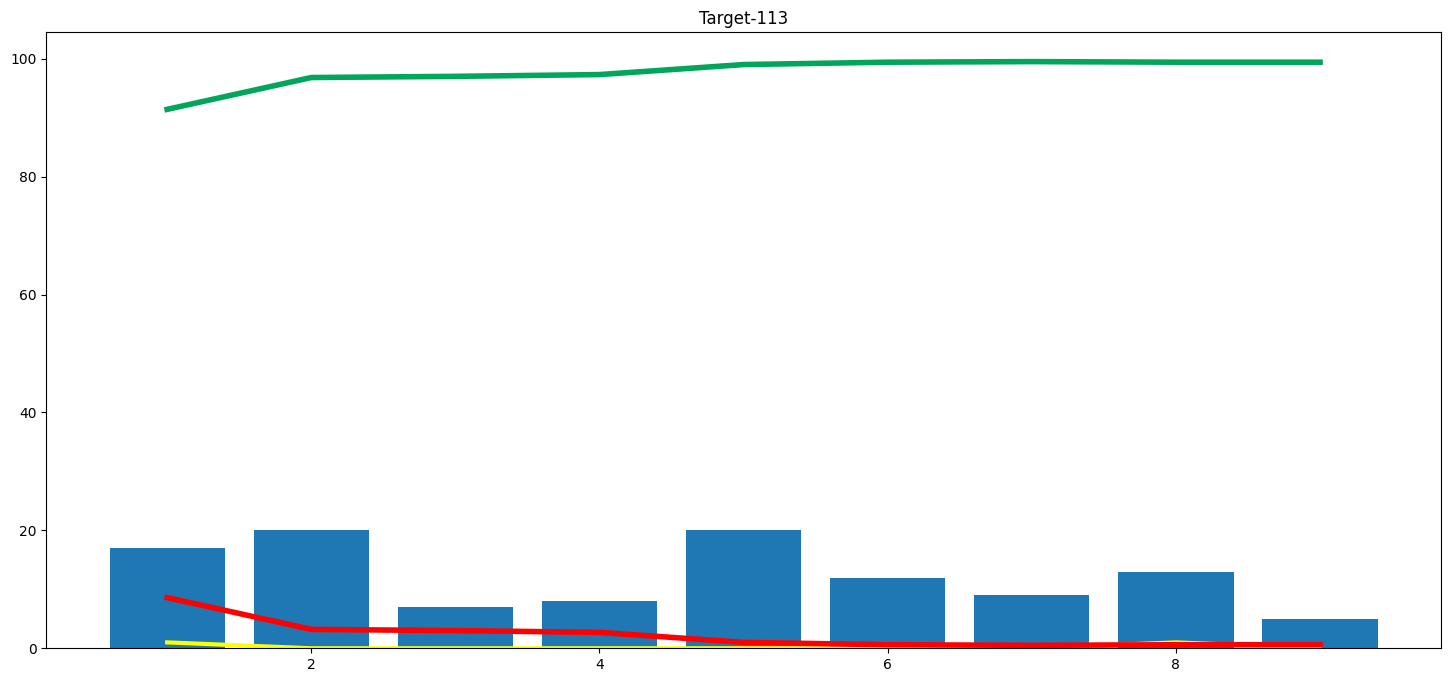

In [125]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,8))
plt.plot(temp_df['end_of_over'],temp_df['wickets_in_over'],color='yellow',linewidth=3)
plt.plot(temp_df['end_of_over'],temp_df['win'],color='#00a65a',linewidth=4)
plt.plot(temp_df['end_of_over'],temp_df['lose'],color='red',linewidth=4)
plt.bar(temp_df['end_of_over'],temp_df['runs_after_over'])
plt.title('Target-' + str(target))